In [1]:
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid")

pd.set_option("display.max_colwidth", 200)

In [2]:
dataset = load_dataset("Tobi-Bueck/customer-support-tickets")

dataset

DatasetDict({
    train: Dataset({
        features: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8'],
        num_rows: 61765
    })
})

In [3]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8'],
        num_rows: 61765
    })
})


In [4]:
df = dataset["train"].to_pandas()

print(df.shape)
df.head()

(61765, 16)


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte einen gravierenden Sicherheitsvorfall melden, der gegenwärtig mehrere Komponenten unserer Infrastruktur betrifft. Betroffene Geräte umfassen Projektoren, ...",Vielen Dank für die Meldung des kritischen Sicherheitsvorfalls und die Bereitstellung der Übersicht über die betroffenen Geräte sowie der ergriffenen ersten Maßnahmen. Wir erkennen die Dringlichke...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to report a significant problem with the centralized account management portal, which currently appears to be offline. This outage is blocking access to...","Thank you for reaching out, <name>. We are aware of the outage affecting the centralized account management system, and our technical team is actively working to resolve the issue. In the meantime...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Features,"Dear Customer Support Team,\n\nI hope this message reaches you well. I am reaching out to request detailed information about the capabilities of your smart home integration products listed on your...","Thank you for your inquiry. Our products support integration with Amazon Alexa, Google Assistant, and Apple HomeKit. Compatibility details can differ depending on the specific item; please let us ...",Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this message finds you well. I am reaching out to request clarification about the billing and payment procedures linked to my account. Recently, I observed so...","We appreciate you reaching out with your billing questions. The billing period generally begins on the first day of the month and concludes on the last day, with payments due by the 10th of the fo...",Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
4,Question About Marketing Agency Software Compatibility,"Dear Support Team,\n\nI hope this message reaches you well. I am reaching out to ask about the compatibility of your products with the specific needs of marketing agencies. Our company is consider...","Thank you for your inquiry. Our product supports integration with major CRM, email marketing, and analytics platforms through APIs and customization options. Please specify the tools you are using...",Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN


In [5]:
df.columns

Index(['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language',
       'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6',
       'tag_7', 'tag_8'],
      dtype='str')

In [6]:
df[["subject", "body", "queue", "priority", "type"]].head(5)

,subject,body,queue,priority,type
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte einen gravierenden Sicherheitsvorfall melden, der gegenwärtig mehrere Komponenten unserer Infrastruktur betrifft. Betroffene Geräte umfassen Projektoren, ...",Technical Support,high,Incident
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to report a significant problem with the centralized account management portal, which currently appears to be offline. This outage is blocking access to...",Technical Support,high,Incident
2,Query About Smart Home System Integration Features,"Dear Customer Support Team,\n\nI hope this message reaches you well. I am reaching out to request detailed information about the capabilities of your smart home integration products listed on your...",Returns and Exchanges,medium,Request
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this message finds you well. I am reaching out to request clarification about the billing and payment procedures linked to my account. Recently, I observed so...",Billing and Payments,low,Request
4,Question About Marketing Agency Software Compatibility,"Dear Support Team,\n\nI hope this message reaches you well. I am reaching out to ask about the compatibility of your products with the specific needs of marketing agencies. Our company is consider...",Sales and Pre-Sales,medium,Problem


In [7]:
df.isna().sum()

subject      5299
body            2
answer      13189
type        13178
queue           0
priority        0
language        0
version     33178
tag_1       13178
tag_2       13237
tag_3       13409
tag_4       17775
tag_5       34129
tag_6       48540
tag_7       55797
tag_8       59293
dtype: int64

In [8]:
df["subject"] = df["subject"].fillna("")
df["body"] = df["body"].fillna("")

df["text"] = df["subject"] + " " + df["body"]

df["text"].head()

0    Wesentlicher Sicherheitsvorfall Sehr geehrtes Support-Team,\n\nich möchte einen gravierenden Sicherheitsvorfall melden, der gegenwärtig mehrere Komponenten unserer Infrastruktur betrifft. Betroffe...
1    Account Disruption Dear Customer Support Team,\n\nI am writing to report a significant problem with the centralized account management portal, which currently appears to be offline. This outage is...
2    Query About Smart Home System Integration Features Dear Customer Support Team,\n\nI hope this message reaches you well. I am reaching out to request detailed information about the capabilities of ...
3    Inquiry Regarding Invoice Details Dear Customer Support Team,\n\nI hope this message finds you well. I am reaching out to request clarification about the billing and payment procedures linked to m...
4    Question About Marketing Agency Software Compatibility Dear Support Team,\n\nI hope this message reaches you well. I am reaching out to ask about the compatibility of your pro

In [9]:
df["text_len_chars"] = df["text"].str.len()

df["text_len_chars"].describe()

count    61765.000000
mean       463.509415
std        227.044165
min          5.000000
25%        278.000000
50%        459.000000
75%        633.000000
max       2284.000000
Name: text_len_chars, dtype: float64

In [10]:
df["text_len_words"] = df["text"].str.split().str.len()

df["text_len_words"].describe()

count    61765.000000
mean        62.429062
std         31.230536
min          1.000000
25%         37.000000
50%         62.000000
75%         87.000000
max        283.000000
Name: text_len_words, dtype: float64

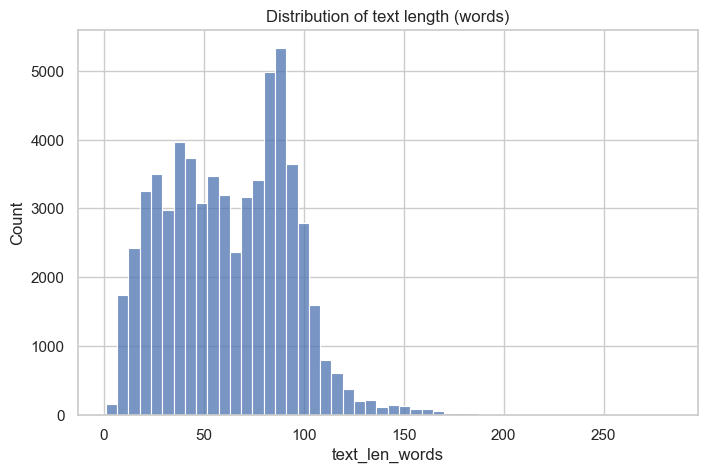

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["text_len_words"], bins=50)
plt.title("Distribution of text length (words)")
plt.show()

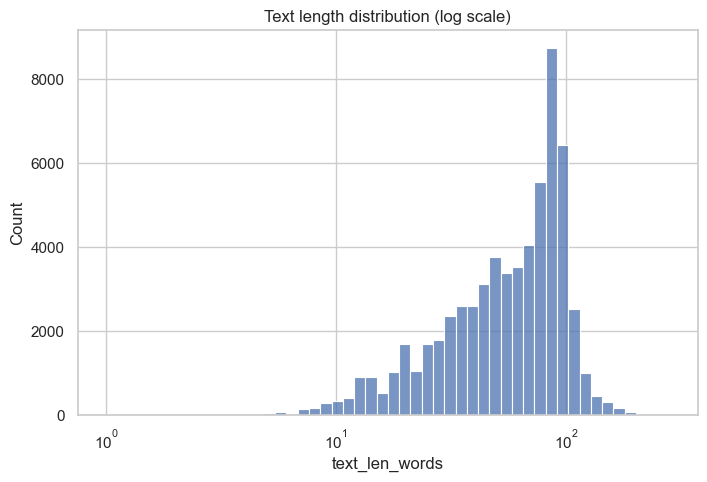

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["text_len_words"], bins=50, log_scale=True)
plt.title("Text length distribution (log scale)")
plt.show()

In [13]:
queue_counts = df["queue"].value_counts()

queue_counts.head(10)

queue
Technical Support                  14186
Product Support                     8960
Customer Service                    7420
IT Support                          5725
Billing and Payments                4874
Returns and Exchanges               2438
Service Outages and Maintenance     1912
Sales and Pre-Sales                 1490
Human Resources                      914
General Inquiry                      668
Name: count, dtype: int64

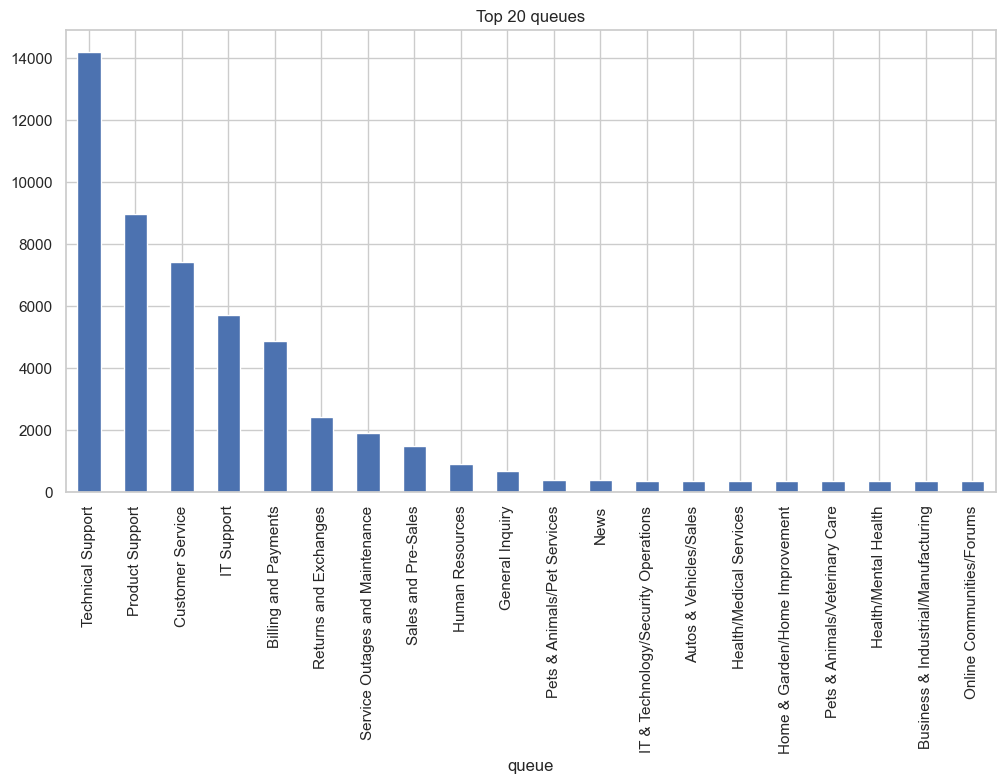

In [14]:
plt.figure(figsize=(12,6))
queue_counts.head(20).plot(kind="bar")
plt.title("Top 20 queues")
plt.show()

In [15]:
df["queue"].nunique()

52

In [16]:
queue_counts.describe()

count       52.000000
mean      1187.788462
std       2570.721592
min        230.000000
25%        294.750000
50%        325.500000
75%        364.250000
max      14186.000000
Name: count, dtype: float64

In [17]:
queue_counts.tail(10)

queue
Jobs & Education/Recruitment            290
Books & Literature/Fiction              289
Beauty & Fitness/Fitness Training       289
Shopping/Retail Stores                  283
People & Society/Culture & Society      283
IT & Technology/Software Development    262
Arts & Entertainment/Movies             262
Home & Garden/Landscaping               256
Sports                                  236
Real Estate                             230
Name: count, dtype: int64

In [18]:
df["priority"].value_counts()

priority
medium      23378
high        21925
low         12765
critical     1914
very_low     1783
Name: count, dtype: int64

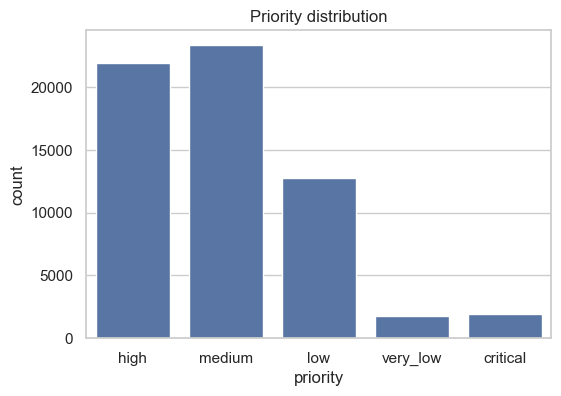

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x="priority", data=df)
plt.title("Priority distribution")
plt.show()

In [20]:
df["type"].value_counts(dropna=False)

type
Incident    19444
Request     13950
NaN         13178
Problem     10196
Change       4997
Name: count, dtype: int64

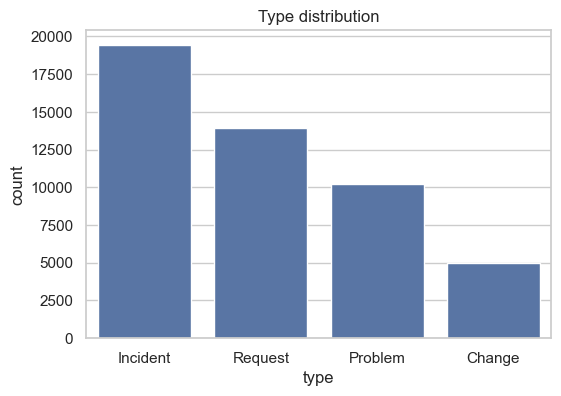

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x="type", data=df)
plt.title("Type distribution")
plt.show()

In [22]:
rare_classes = queue_counts[queue_counts < 50]

len(rare_classes)

0

In [23]:
rare_classes

Series([], Name: count, dtype: int64)

In [24]:
for i in range(3):
    print("QUEUE:", df.iloc[i]["queue"])
    print("PRIORITY:", df.iloc[i]["priority"])
    print("TYPE:", df.iloc[i]["type"])
    print("TEXT:", df.iloc[i]["text"][:500])
    print("\n" + "-"*80 + "\n")

QUEUE: Technical Support
PRIORITY: high
TYPE: Incident
TEXT: Wesentlicher Sicherheitsvorfall Sehr geehrtes Support-Team,\n\nich möchte einen gravierenden Sicherheitsvorfall melden, der gegenwärtig mehrere Komponenten unserer Infrastruktur betrifft. Betroffene Geräte umfassen Projektoren, Bildschirme und Speicherlösungen auf Cloud-Plattformen. Der Grund für die Annahme ist, dass der Vorfall eine potenzielle Datenverletzung im Zusammenhang mit einer Cyberattacke darstellt, was ein erhebliches Risiko für sensible Informationen und den laufenden Geschäftsbetr

--------------------------------------------------------------------------------

QUEUE: Technical Support
PRIORITY: high
TYPE: Incident
TEXT: Account Disruption Dear Customer Support Team,\n\nI am writing to report a significant problem with the centralized account management portal, which currently appears to be offline. This outage is blocking access to account settings, leading to substantial inconvenience. I have attempted to lo

In [25]:
df["text"].sample(5).tolist()

['Sicherheitsverstoß im Krankenhaus-System Es wurde ein Sicherheitsverstoß festgestellt, der die Sicherheit der Patientendaten gefährdet hat.',
 'Trouble with WhatsApp Desktop Experienced technical difficulties during a marketing campaign coordination call involving WhatsApp Desktop. The issue might have arisen from recent software updates. Tried reinstalling the application and rebooting the system, but the problem still persists. We would appreciate your assistance in resolving this matter.',
 'Sporadische Scannerfehler am Point of Sale Sehr geehrtes Support-Team,\\n\\nich schreibe Ihnen, um ein wiederkehrendes Problem mit dem Barcode-Scanner an unserer Kasse zu melden. Der Scanner weist zeitweise Fehlfunktionen auf, was zu Preisungenauigkeiten während des Bezahlvorgangs führt. Dieses Problem ist besonders angesichts unserer aktuellen Influencer-Promotion besorgniserregend, bei der eine genaue Umsatzverfolgung unerlässlich ist. Wir haben diese Scannerfehler in der letzten Woche spora

## EDA conclusions

The dataset contains **61,765 customer support tickets** collected from an IT service management system.

### Dataset structure
Each ticket consists of:
- **subject** — short title of the issue
- **body** — detailed ticket description
- **queue** — target department/team (main prediction task)
- **priority** — urgency level of the ticket
- **type** — category of the issue (Incident, Request, Problem, Change, Unknown)

For modeling, the textual input was constructed by concatenating **subject and body** fields.

---

### Text characteristics

Text length analysis shows that:
- most tickets are **relatively short**
- the majority of texts contain **tens of words**
- there is a **long tail of longer tickets**

This distribution is typical for customer support datasets where many issues are short requests while some contain detailed explanations.

---

### Queue distribution (main task)

The main prediction target **queue** contains **52 unique classes**.

EDA reveals that the distribution is **highly imbalanced**:
- several queues contain **many examples**
- many queues appear **very rarely**
- some queues have **fewer than 50 samples**

This strong imbalance justifies the use of **Macro-F1** as the main evaluation metric, since accuracy alone would favor frequent classes.

---

### Priority distribution

The **priority** label contains **5 classes**.

The distribution is moderately imbalanced, with some priority levels occurring significantly more frequently than others. However, the imbalance is less severe than in the `queue` label.

---

### Type distribution

The **type** label also contains **5 classes**:

- Incident
- Request
- Problem
- Change
- Unknown

The `Unknown` class represents missing or unspecified ticket type labels.

---

### Language characteristics

Example tickets show that the dataset contains a **mixture of English and German texts**, which is important when selecting language models later.

---

### Key implications for modeling

The EDA suggests several important considerations for modeling:

- The **queue prediction task is a multi-class classification problem with strong class imbalance**.
- **Macro-F1** is an appropriate evaluation metric because it treats all classes equally.
- A **TF-IDF + linear model baseline** is a reasonable starting point for text classification.
- Transformer-based models may better capture semantic information in longer and more complex tickets.